✅ 图表已成功保存为高清 PNG 文件: host_distribution.png


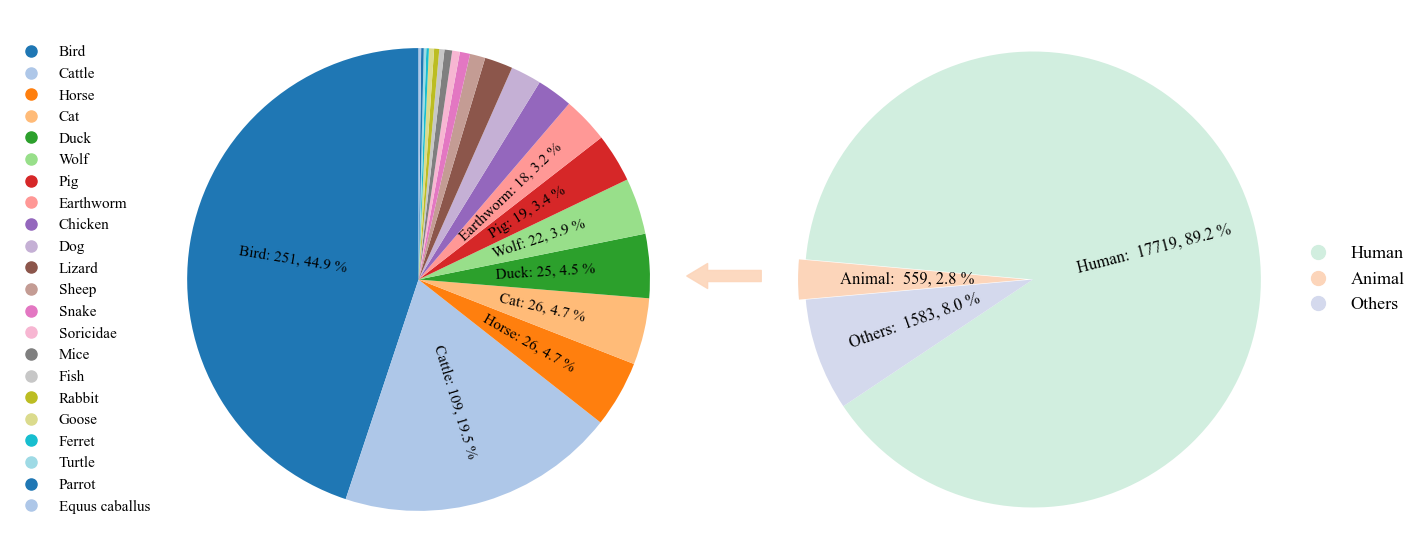

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
from matplotlib.patches import FancyArrowPatch

# ==========================================
# 0. 全局字体设置
# ==========================================
# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
# 确保在保存图片时，负号等特殊符号也能正常显示
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. 读取并处理数据
# ==========================================
# 读取包含数据的 CSV 文件
file_path = r'D:\A.baumannii\data\metadata.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"找不到文件: {file_path}，请检查路径。")
    exit()

# 指定需要处理的列名
host_col = 'host_1'

# 【清洗数据】去除前后空格，并强制首字母大写，统一视觉规范
df[host_col] = df[host_col].astype(str).str.strip().str.capitalize()

# ================= 关键词定义 =================
# 定义分类关键词（忽略大小写，因为判定逻辑里做了 lower() 处理）
human_keywords = ['Human', 'Homo sapiens', '人']

# 将 environment 和 Lab strain 加入到 Others 分类中，避免被归为 Animal
others_keywords = [
    'Environment', 'Lab strain', 'Water', 'Soil', 'Food', 
    'Unknown', 'Missing', 'Others', 'Other', 
    '环境', '水', '未知', '其它', '其他', 'Nan'
]
# ============================================

def categorize_host(host):
    """将宿主数据分类为 Human, Others 和 Animal"""
    if pd.isna(host) or host == 'Nan':
        return 'Others'
    host_str = str(host).strip()
    
    # 转换为小写进行匹配，提高鲁棒性
    if any(k.lower() in host_str.lower() for k in human_keywords):
        return 'Human'
    elif any(k.lower() in host_str.lower() for k in others_keywords):
        return 'Others'
    else:
        # 既不是人，也不是环境/实验菌株/其他等，则归为动物
        return 'Animal' 

# 应用分类函数生成新列
df['Main_Category'] = df[host_col].apply(categorize_host)

# 统计主分类数据
main_counts = df['Main_Category'].value_counts()
for cat in ['Human', 'Animal', 'Others']:
    if cat not in main_counts:
        main_counts[cat] = 0
# 固定展示顺序为: Human, Animal, Others
main_counts = main_counts[['Human', 'Animal', 'Others']] 

# 统计动物子分类数据
animal_df = df[df['Main_Category'] == 'Animal']
animal_counts = animal_df[host_col].value_counts()

# ==========================================
# 2. 绘制平面图表
# ==========================================
# 创建画布和两个子图 (1行2列)
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(16, 7))

# 【优化间距】增大 wspace 使两图之间有足够的空间放置箭头
plt.subplots_adjust(left=0.15, right=0.85, wspace=0.2) 

# -----------------
# 绘制右侧主饼图 (ax1)
# -----------------
main_labels = main_counts.index.tolist()
main_values = main_counts.values.tolist()
total_main = sum(main_values)

# 定义主图的颜色
color_dict_main = {
    'Human': '#d1eedf',   # 浅薄荷绿
    'Animal': '#fcd5ba',  # 浅桃粉色
    'Others': '#d4d9ed'   # 浅紫蓝色
}
plot_colors_main = [color_dict_main[l] for l in main_labels]

# 稍微突出显示 'Animal' 扇区
explode_main = [0.03 if l == 'Animal' else 0 for l in main_labels]

# 【动态计算旋转角度】确保无论比例怎么变，Animal 扇区都正对着左侧 (180度)
human_val = main_values[0]
animal_val = main_values[1]
if total_main > 0:
    # 按照 Human -> Animal -> Others 的逆时针顺序计算 Animal 中心的偏移量
    offset_angle = (human_val + animal_val / 2) / total_main * 360
    # 使该中心点正好处于 180 度
    startangle_main = 180 - offset_angle
else:
    startangle_main = 90

# 绘制平面饼图
wedges1, _ = ax1.pie(main_values, explode=explode_main, colors=plot_colors_main, startangle=startangle_main)

# 在扇区内部添加文字说明
main_pie_labels = [f"{l}:  {v}, {v/total_main*100:.1f} %" if v > 0 else "" for l, v in zip(main_labels, main_values)]
for i, p in enumerate(wedges1):
    if main_values[i] == 0: continue
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    
    # 计算文字旋转角度，使其易于阅读
    rot = ang
    if 90 < rot < 270:
        rot -= 180
    
    r = 0.55 # 文字距离圆心的比例
    ax1.text(x * r, y * r, main_pie_labels[i], ha='center', va='center', rotation=rot, fontsize=12)

# 添加右侧图例
legend_handles_main = [mlines.Line2D([], [], color=c, marker='o', linestyle='None', markersize=10) for c in plot_colors_main]
ax1.legend(legend_handles_main, main_labels, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=13)

# -----------------
# 绘制左侧动物子饼图 (ax2)
# -----------------
animal_labels = animal_counts.index.tolist()
animal_values = animal_counts.values.tolist()
total_animal = sum(animal_values)

if total_animal > 0:
    # 为动物分类生成多样化的颜色集
    cmap = plt.get_cmap('tab20')
    colors_animal = [cmap(i % 20) for i in range(len(animal_labels))]

    wedges2, _ = ax2.pie(animal_values, colors=colors_animal, startangle=90)

    animal_pie_labels = [f"{l}: {v}, {v/total_animal*100:.1f} %" for l, v in zip(animal_labels, animal_values)]

    for i, p in enumerate(wedges2):
        # 为防止重叠，只为占比大于 3% 的扇区在内部添加文字
        pct = animal_values[i] / total_animal * 100
        if pct > 3: 
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            
            rot = ang
            if 90 < rot < 270:
                rot -= 180
                
            r = 0.55 
            ax2.text(x * r, y * r, animal_pie_labels[i], ha='center', va='center', rotation=rot, fontsize=11)

    # 添加最左侧图例
    legend_handles_animal = [mlines.Line2D([], [], color=c, marker='o', linestyle='None', markersize=8) for c in colors_animal]
    ax2.legend(legend_handles_animal, animal_labels, loc="center right", bbox_to_anchor=(0, 0.5), frameon=False, fontsize=11, labelspacing=0.5)
else:
    ax2.text(0, 0, "No Animal Data", ha='center', va='center', fontsize=14)

# -----------------
# 绘制中间的指示箭头
# -----------------
# 【优化坐标】精确控制箭头的绝对位置，使其完全落于两饼图中间隙，不产生重叠
arrow = FancyArrowPatch((0.525, 0.5), (0.475, 0.5), transform=fig.transFigure,
                        arrowstyle='simple,head_width=18,head_length=15,tail_width=8',
                        color=color_dict_main['Animal'], alpha=0.9, zorder=10)
fig.patches.append(arrow)

# 确保饼图是正圆形
ax1.axis('equal')
ax2.axis('equal')


# ==========================================
# 3. 保存和显示图表
# ==========================================
output_filename = 'host_distribution.png'

# 保存为高清 PNG 图片 (dpi=300 可以保证学术论文或打印的高清晰度)
# bbox_inches='tight' 可确保所有元素(如图例、标签)都被包含在图片内，不会被切掉
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ 图表已成功保存为高清 PNG 文件: {output_filename}")

# 显示图表
plt.show()


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
from matplotlib.patches import FancyArrowPatch


# ==========================================
# 0. 全局字体设置
# ==========================================

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False


# ==========================================
# 1. 读取并处理数据
# ==========================================

file_path = (
    r'D:\python\敏感性分析'
    r'\ab_processedd_1_representatives_with_ST_1.csv'
)

try:
    df = pd.read_csv(file_path)

except FileNotFoundError:
    print(f"找不到文件: {file_path}，请检查路径。")
    raise SystemExit


# 宿主列
host_col = 'host_1'


# ==========================================
# 清洗 host 数据
# ==========================================

# 注意：
# 不建议先直接 capitalize() 再进行判断，
# 这里保留原始文字，只去除首尾空格。
df[host_col] = (
    df[host_col]
    .astype(str)
    .str.strip()
)


# ==========================================
# 2. 定义分类关键词
# ==========================================

# Human
human_keywords = [
    'Human',
    'Homo sapiens',
    '人'
]


# Environment
# Environment 单独作为一个主分类
environment_keywords = [
    'Environment',
    '环境'
]


# Others
# Environment 已经从这里移除
others_keywords = [
    'Lab strain',
    'Water',
    'Soil',
    'Food',
    'Unknown',
    'Missing',
    'Others',
    'Other',
    '水',
    '未知',
    '其它',
    '其他',
    'Nan'
]


# ==========================================
# 3. 分类函数
# ==========================================

def categorize_host(host):
    """
    将 host 分成四个主分类：

    Human
    Animal
    Environment
    Others
    """

    # 缺失值
    if pd.isna(host):
        return 'Others'

    host_str = str(host).strip()

    # 空字符串
    if host_str == '':
        return 'Others'

    # nan
    if host_str.lower() == 'nan':
        return 'Others'

    # ------------------------------
    # Human
    # ------------------------------
    if any(
        keyword.lower() in host_str.lower()
        for keyword in human_keywords
    ):
        return 'Human'

    # ------------------------------
    # Environment
    # ------------------------------
    elif any(
        keyword.lower() in host_str.lower()
        for keyword in environment_keywords
    ):
        return 'Environment'

    # ------------------------------
    # Others
    # ------------------------------
    elif any(
        keyword.lower() in host_str.lower()
        for keyword in others_keywords
    ):
        return 'Others'

    # ------------------------------
    # 剩余全部作为 Animal
    # ------------------------------
    else:
        return 'Animal'


# 应用分类
df['Main_Category'] = df[host_col].apply(
    categorize_host
)


# ==========================================
# 4. 主分类统计
# ==========================================

main_counts = (
    df['Main_Category']
    .value_counts()
)


# 固定主分类顺序
main_categories = [
    'Human',
    'Animal',
    'Environment',
    'Others'
]


# 如果某个分类没有数据，则补 0
for category in main_categories:

    if category not in main_counts:
        main_counts[category] = 0


# 按固定顺序排列
main_counts = main_counts[
    main_categories
]


# ==========================================
# 5. Animal 子分类统计
# ==========================================

animal_df = df[
    df['Main_Category'] == 'Animal'
].copy()


animal_counts = (
    animal_df[host_col]
    .value_counts()
)


# ==========================================
# 6. 输出统计结果
# ==========================================

print("\n===================================")
print("Main Category Counts")
print("===================================")

print(main_counts)


print("\n===================================")
print("Animal Subcategory Counts")
print("===================================")

print(animal_counts)


# ==========================================
# 7. 创建画布
# ==========================================

fig, (ax2, ax1) = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)


# 调整整体布局
plt.subplots_adjust(
    left=0.15,
    right=0.85,
    wspace=0.20
)


# ============================================================
# 8. 右侧主饼图
# ============================================================

main_labels = (
    main_counts
    .index
    .tolist()
)

main_values = (
    main_counts
    .values
    .tolist()
)

total_main = sum(
    main_values
)


# ==========================================
# 主分类颜色
# ==========================================

color_dict_main = {

    # Human
    'Human': '#d1eedf',

    # Animal
    'Animal': '#fcd5ba',

    # Environment
    'Environment': '#f5e6a8',

    # Others
    'Others': '#d4d9ed'
}


plot_colors_main = [
    color_dict_main[label]
    for label in main_labels
]


# ==========================================
# Animal 扇区稍微突出
# ==========================================

explode_main = [

    0.03
    if label == 'Animal'
    else 0

    for label in main_labels
]


# ==========================================
# 9. 动态计算旋转角度
#
# 目标：
# 让 Animal 扇区中心朝向左边，
# 即 180°
# ==========================================

human_val = main_counts['Human']
animal_val = main_counts['Animal']


if total_main > 0:

    # Human 在 Animal 前面，
    # 所以 Animal 中心角度偏移为：
    offset_angle = (
        human_val
        +
        animal_val / 2
    ) / total_main * 360

    # Animal 中心固定到 180°
    startangle_main = (
        180
        -
        offset_angle
    )

else:

    startangle_main = 90


# ==========================================
# 10. 绘制主饼图
# ==========================================

wedges1, _ = ax1.pie(

    main_values,

    explode=explode_main,

    colors=plot_colors_main,

    startangle=startangle_main,

    wedgeprops={
        'linewidth': 0
    }
)


# ==========================================
# 11. 创建主饼图标签
# ==========================================

if total_main > 0:

    main_pie_labels = [

        (
            f"{label}: {value}, "
            f"{value / total_main * 100:.1f} %"
        )

        if value > 0

        else ""

        for label, value
        in zip(
            main_labels,
            main_values
        )
    ]

else:

    main_pie_labels = [
        ""
        for _ in main_labels
    ]


# ============================================================
# 12. 主饼图内部文字
#
# 重点修改：
#
# Human：
#     按原来的方式放在扇区内部
#
# Animal：
#     水平显示，并稍微向上
#
# Others：
#     水平显示
#
# Environment：
#     水平显示，并放到 Others 下方
#
# ============================================================

for i, wedge in enumerate(wedges1):

    value = main_values[i]

    if value == 0:
        continue

    label = main_labels[i]


    # --------------------------------------
    # 当前扇区中心角度
    # --------------------------------------

    angle = (
        wedge.theta1
        +
        wedge.theta2
    ) / 2


    x = np.cos(
        np.deg2rad(angle)
    )

    y = np.sin(
        np.deg2rad(angle)
    )


    # --------------------------------------
    # Human
    # --------------------------------------

    if label == 'Human':

        r = 0.58

        text_x = x * r
        text_y = y * r

        rotation = angle

        # 防止文字倒着显示
        if 90 < rotation < 270:
            rotation -= 180

        ax1.text(

            text_x,
            text_y,

            main_pie_labels[i],

            ha='center',
            va='center',

            rotation=rotation,

            fontsize=12
        )


    # --------------------------------------
    # Animal
    #
    # 水平显示
    # --------------------------------------

    elif label == 'Animal':

        # 小分类集中在左侧，
        # 因此直接人工指定文字位置，
        # 比跟随极窄扇区的位置更稳定。

        ax1.text(

            -0.43,
            0.055,

            main_pie_labels[i],

            ha='center',
            va='center',

            rotation=0,

            fontsize=12
        )


    # --------------------------------------
    # Others
    #
    # 放在 Animal 下方
    # --------------------------------------

    elif label == 'Others':

        ax1.text(

            -0.43,
            -0.13,

            main_pie_labels[i],

            ha='center',
            va='center',

            rotation=0,

            fontsize=12
        )


    # --------------------------------------
    # Environment
    #
    # 明确放在 Others 下面
    # --------------------------------------

    elif label == 'Environment':

        ax1.text(

            -0.43,
            -0.225,

            main_pie_labels[i],

            ha='center',
            va='center',

            rotation=0,

            fontsize=12
        )


# ==========================================
# 13. 主饼图右侧图例
# ==========================================

legend_handles_main = [

    mlines.Line2D(

        [],
        [],

        color=color,

        marker='o',

        linestyle='None',

        markersize=10
    )

    for color
    in plot_colors_main
]


ax1.legend(

    legend_handles_main,

    main_labels,

    loc='center left',

    bbox_to_anchor=(
        1,
        0.5
    ),

    frameon=False,

    fontsize=13
)


# ============================================================
# 14. 左侧 Animal 子分类饼图
# ============================================================

animal_labels = (
    animal_counts
    .index
    .tolist()
)

animal_values = (
    animal_counts
    .values
    .tolist()
)

total_animal = sum(
    animal_values
)


if total_animal > 0:

    # ======================================
    # Animal 子分类颜色
    # ======================================

    cmap = plt.get_cmap(
        'tab20'
    )


    colors_animal = [

        cmap(i % 20)

        for i
        in range(
            len(animal_labels)
        )
    ]


    # ======================================
    # 绘制 Animal 饼图
    # ======================================

    wedges2, _ = ax2.pie(

        animal_values,

        colors=colors_animal,

        startangle=90,

        wedgeprops={
            'linewidth': 0
        }
    )


    # ======================================
    # Animal 标签
    # ======================================

    animal_pie_labels = [

        (
            f"{label}: {value}, "
            f"{value / total_animal * 100:.1f} %"
        )

        for label, value
        in zip(
            animal_labels,
            animal_values
        )
    ]


    # ======================================
    # Animal 内部文字
    #
    # 仅显示占比 > 3% 的分类
    # ======================================

    for i, wedge in enumerate(wedges2):

        pct = (
            animal_values[i]
            /
            total_animal
            *
            100
        )


        if pct > 3:

            angle = (
                wedge.theta1
                +
                wedge.theta2
            ) / 2


            x = np.cos(
                np.deg2rad(angle)
            )

            y = np.sin(
                np.deg2rad(angle)
            )


            rotation = angle


            # 防止文字倒置
            if 90 < rotation < 270:
                rotation -= 180


            r = 0.55


            ax2.text(

                x * r,
                y * r,

                animal_pie_labels[i],

                ha='center',
                va='center',

                rotation=rotation,

                fontsize=11
            )


    # ======================================
    # Animal 左侧图例
    # ======================================

    legend_handles_animal = [

        mlines.Line2D(

            [],
            [],

            color=color,

            marker='o',

            linestyle='None',

            markersize=8
        )

        for color
        in colors_animal
    ]


    ax2.legend(

        legend_handles_animal,

        animal_labels,

        loc='center right',

        bbox_to_anchor=(
            0,
            0.5
        ),

        frameon=False,

        fontsize=11,

        labelspacing=0.5
    )


else:

    ax2.text(

        0,
        0,

        'No Animal Data',

        ha='center',
        va='center',

        fontsize=14
    )


# ============================================================
# 15. 中间箭头
#
# Animal 主分类
#       ↓
# Animal 子分类
# ============================================================

arrow = FancyArrowPatch(

    # 起点：右边
    (0.525, 0.5),

    # 终点：左边
    (0.475, 0.5),

    transform=fig.transFigure,

    arrowstyle=(
        'simple,'
        'head_width=18,'
        'head_length=15,'
        'tail_width=8'
    ),

    color=color_dict_main['Animal'],

    alpha=0.9,

    zorder=10
)


fig.patches.append(
    arrow
)


# ==========================================
# 16. 保证两个饼图都是正圆
# ==========================================

ax1.axis('equal')
ax2.axis('equal')


# ==========================================
# 17. 保存图片
# ==========================================

output_filename = (
    'host_distribution.png'
)


plt.savefig(

    output_filename,

    dpi=300,

    bbox_inches='tight',

    facecolor='white'
)


print(
    "\n✅ 图表已成功保存为高清 PNG 文件："
    f"{output_filename}"
)


# ==========================================
# 18. 显示图片
# ==========================================

plt.show()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd5 in position 34250: invalid continuation byte